# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:** 
Davi Oliveira Sad - 2023096043 <br>
Gabrielly Xavier dos Santos - 2024023724 <br>
Júlia Luíza Costa de Toledo - 2024008431 <br>
Rafael Vinicius de Sant’Ana Mathias - 2023087834 <br> 
**Dataset:** Mushroom    
**Tarefa de mineração:** Classificação   
**Data da entrega:** 21/06/2026 

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
| :--- | :--- |
| **Nome do dataset** | Mushroom Dataset (Agaricus and Lepiota) |
| **Link público do dataset** | https://archive.ics.uci.edu/dataset/73/mushroom |
| **Número de linhas** | 8.124 |
| **Número de colunas** | 22 atributos preditivos + 1 variável-alvo |
| **Tarefa de mineração** | Classificação |
| **Diretriz 1 de IA responsável** | Segurança, confiabilidade e robustez |
| **Diretriz 2 de IA responsável** | Transparência e explicabilidade |
| **LLM usada na Fase 2 — baseline** | Google Gemini |
| **LLM usada na Fase 2 — guiada** | Google Gemini |
| **Notebook da Fase 2** | https://github.com/DaviOSad/Mushroom-Classification/blob/main/TP3_Fase2_Grupo11.ipynb |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
| :--- | :---: | :---: | :--- |
| **Exclusão de modelos Caixa-Preta** (*Random Forest*) | Trilha B | **Sim** | Modelos ensemble violam a diretriz de Transparência. Mantivemos apenas modelos "caixa-branca" para permitir auditoria direta das regras preditivas. |
| **Não-imputação de dados faltantes** na coluna `stalk-root` | Trilha B | **Sim** | Preencher as interrogações `?` com a moda inventaria dados e geraria correlações falsas e perigosas, violando a diretriz de Segurança. |
| **Uso exclusivo de One-Hot Encoding** | Grupo / Corrigido da Trilha A | **Sim** | Evita que o algoritmo interprete ordens e distâncias inexistentes na biologia (Label Encoding), preservando a semântica nominal correta. |
| **Calibração de Limiar de Decisão em 0.02** | Trilha B | **Sim** | Decisão mestre do projeto. Joga a fronteira de decisão a favor da preservação da vida, garantindo o Recall de 100% (zero Falsos Negativos). |
| **Ajuste de Penalização** (`class_weight`) para 20 | Grupo / Refinado da Trilha B | **Sim** | Reduzimos a sugestão inicial de 50 para 20. O teste empírico provou que o limiar de 0.02 absorve o impacto e mantém o Recall em 100%, diminuindo alarmes falsos. |
| **Restrição de nós folhas** (`min_samples_leaf=1%`) | Trilha B | **Sim** | Mantivemos a exigência de que cada folha tenha ao menos 1% das amostras. Isso evita que a árvore crie regras baseadas em ruídos estatísticos ou exceções raras, garantindo a generalização e robustez. |

In [58]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = "agaricus-lepiota.data"

TASK_TYPE = "classificacao"

# Coluna-alvo que indica a edibilidade (e/p).
TARGET_COLUMN = "class"

TRANSACTION_COLUMN = None

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")
print(f"TARGET_COLUMN = {TARGET_COLUMN}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

Configuração inicial carregada.
TASK_TYPE = classificacao
DATA_PATH = agaricus-lepiota.data
TARGET_COLUMN = class
OUTPUT_DIR = outputs


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** A identificação correta de cogumelos é uma tarefa crítica de segurança alimentar. Em situações de campo, um erro de classificação pode levar ao consumo acidental de uma espécie tóxica, com consequências graves para a saúde humana.

- **Problema:** O objetivo deste trabalho é construir um classificador capaz de distinguir cogumelos comestíveis de venenosos a partir de características morfológicas e ecológicas. Como todas as variáveis da base são categóricas, a tarefa exige codificação adequada e avaliação cuidadosa do modelo para reduzir ao máximo os falsos negativos, isto é, casos em que um cogumelo venenoso seria classificado como comestível.

- **Possíveis interessados:** Consumidores, micologistas, profissionais de saúde, órgãos de vigilância sanitária e desenvolvedores de aplicativos de apoio à identificação de espécies.

- **Decisões apoiadas pela análise:** O modelo pode apoiar triagens iniciais de segurança, orientar guias de identificação, auxiliar aplicativos de consulta em campo e servir como ferramenta educacional para reconhecer padrões associados à toxicidade.

- **Limitações iniciais conhecidas:** A base é composta apenas por atributos nominais, não contém medições laboratoriais e descreve apenas uma fração da diversidade de cogumelos existente. Além disso, o atributo stalk-root possui valores ausentes representados por '?', o que exige tratamento específico antes da modelagem.

### Ajustes em relação à Fase 2

O problema central e o objetivo analítico foram mantidos. No entanto, o escopo da modelagem foi refinado. Na concepção inicial, o objetivo era puramente preditivo (equilíbrio estatístico e maximização de métricas globais). Após a Fase 2, o escopo passou a integrar travas de segurança ativas: percebemos que não basta classificar a edibilidade de forma genérica; é imperativo garantir que o modelo não gere falsos negativos catastróficos (risco fatal à saúde) e não penalize excessivamente a precisão de espécimes comestíveis por excesso de zelo matemático (ajuste de sensibilidade através da calibração do peso de classe em 20 e fixação do limiar preventivo de risco em 0.02).

## 1.2 Dataset, origem e características gerais

### Identificação do dataset

- **Nome:** Mushroom Dataset (Agaricus and Lepiota)
- **Fonte:** UCI Machine Learning Repository (Original do Audubon Society Field Guide - 1981)
- **Link público:** https://archive.ics.uci.edu/dataset/73/mushroom
- **Data de acesso ou download:** 05/06/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| **O que cada linha representa?** | Um espécime isolado de cogumelo coletado com suas propriedades morfológicas e ecológicas registradas. |
| **O que cada coluna representa?** | Atributos físicos observáveis do fungo ou dados sobre o ambiente onde ele prolifera. |
| **Número de instâncias** | 8.124 linhas |
| **Número de atributos** | 22 atributos preditivos + 1 variável-alvo (23 colunas originais) |
| **Tipos principais de atributos** | Estritamente categóricos e nominais (representados por códigos de letras). |
| **Existe variável-alvo?** | Sim. A coluna `class`, indicando se o espécime é comestível (`e`) ou venenoso (`p`). |
| **Existem atributos sensíveis ou identificadores?** | Não. Por se tratar de uma base de dados estritamente botânica, não há registros de dados pessoais ou sensíveis. |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
| :--- | :--- | :--- | :---: | :--- |
| `class` | Categórica | Edibilidade do cogumelo: comestível (`e`) ou venenoso (`p`). | **ALVO** | Variável-alvo binária da tarefa de classificação. |
| `cap-shape` | Categórica | Formato do chapéu (sino, cônico, convexo, plano, afundado, saliente). | Feature | Atributo morfológico visual inicial. |
| `cap-surface` | Categórica | Superfície do chapéu (fibrosa, sulcada, escamosa, lisa). | Feature | Complemento da análise estrutural externa. |
| `cap-color` | Categórica | Cor do chapéu (marrom, bege, cinza, branco, amarelo etc.). | Feature | Mapeamento cromático (10 categorias distintas). |
| `bruises?` | Categórica | Indica presença (`t`) ou ausência (`f`) de manchas/hematomas. | Feature | Atributo binário de fácil verificação em campo. |
| `odor` | Categórica | Aroma exalado (amêndoa, anis, creosoto, fétido, nenhum, pungente etc.). | Feature | O atributo de maior ganho de informação para a tarefa. |
| `gill-attachment` | Categórica | Tipo de fixação das lâminas no caule. | Feature | Caracterização da anatomia interna do fungo. |
| `gill-spacing` | Categórica | Espaçamento entre as lâminas (fechado, aglomerado, distante). | Feature | Indicador taxonômico estrutural. |
| `gill-size` | Categórica | Tamanho das lâminas (largo ou estreito). | Feature | Diferenciação morfológica dicotômica. |
| `gill-color` | Categórica | Cor das lâminas (preto, marrom, rosa, branco, amarelo etc.). | Feature | Alta cardinalidade (12 valores únicos). |
| `stalk-shape` | Categórica | Formato do caule (afunilado ou alargado). | Feature | Geometria do estipe. |
| `stalk-root` | Categórica | Tipo de raiz do estipe. | Feature | Contém o caractere `?` tratado como "Desconhecido". |
| `stalk-surface-above-ring` | Categórica | Textura do caule acima do anel do cogumelo. | Feature | Indicador tátil de superfície superior. |
| `stalk-surface-below-ring` | Categórica | Textura do caule abaixo do anel do cogumelo. | Feature | Indicador tátil de superfície inferior. |
| `stalk-color-above-ring` | Categórica | Cor do caule acima do anel. | Feature | Componente cromático superior do estipe. |
| `stalk-color-below-ring` | Categórica | Cor do caule abaixo do anel. | Feature | Componente cromático inferior do estipe. |
| `veil-type` | Categórica | Tipo de véu do fungo (parcial ou universal). | **REMOVIDA** | Removida na Fase 2 por apresentar variância zero (100% parcial). |
| `veil-color` | Categórica | Cor do véu do cogumelo. | Feature | Apresenta forte desbalanceamento (>90% branco). |
| `ring-number` | Categórica | Quantidade de anéis presentes no caule (nenhum, um, dois). | Feature | Única variável nominal com ordem quantitativa real. |
| `ring-type` | Categórica | Tipo de anel do estipe (evanescente, grande, pendente, nenhum etc.). | Feature | Padrão altamente informativo para identificação. |
| `spore-print-color` | Categórica | Cor do pó deixado pela impressão dos esporos. | Feature | Forte marcador biológico associado ao risco de toxicidade. |
| `population` | Categórica | Padrão populacional de crescimento do fungo. | Feature | Contexto ecológico de proliferação biológica. |
| `habitat` | Categórica | Ambiente onde a espécie se desenvolve (gramado, floresta, lixo etc.). | Feature | Mapeamento do nicho ecológico da espécie. |



## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
| :--- | :--- | :--- | :--- |
| **Segurança, confiabilidade e robustez** | O custo do erro neste domínio é assimétrico e potencialmente fatal. Um falso negativo (classificar um cogumelo venenoso como comestível) pode levar a óbito, exigindo tolerância zero para falhas críticas. | Determinou o abandono da Acurácia global como métrica de sucesso, guiando o pipeline para a otimização do Recall e do F5-Score. Influenciou diretamente na implementação de travas matemáticas ativas no código (ajuste de limiar e pesos de classe). | Fixação do limiar preventivo de risco em 0.02 e configuração de `class_weight={'e': 1, 'p': 20}`, garantindo a marca de **0 Falsos Negativos** (Recall de 100.00%) nos testes. |
| **Transparência e explicabilidade** | A tomada de decisão algorítmica precisa ser auditável por micologistas e compreensível para leigos, garantindo que o modelo decida com base em critérios biológicos reais e não em ruídos. | Barrou a aplicação de modelos complexos de "caixa-preta" (como Random Forest ou XGBoost), restringindo o escopo técnico do projeto exclusivamente a algoritmos interpretáveis "caixa-branca". | Escolha e execução da Árvore de Decisão (com extração de regras textuais IF-THEN) e da Regressão Logística (com cálculo de Odds Ratio para os coeficientes). |

### Análise

A incorporação ativa das diretrizes de IA Responsável alterou de forma profunda e estrutural o pipeline de ciência de dados desenvolvido pelo grupo, transformando um problema de otimização estatística convencional em um sistema de mitigação de riscos humanos.

1. **Alterações no Pipeline Técnico:** Se tivéssemos seguido a abordagem puramente técnica e comercial da Trilha Baseline, teríamos optado por um modelo Random Forest com limiar padrão de 0.5. Essa escolha ocultaria pequenos volumes de falsos negativos sob uma acurácia enganosamente alta de 99%. As diretrizes forçaram a reconfiguração dos hiperparâmetros de penalização e a queda do threshold para 2%, alterando o comportamento do classificador para um modo estritamente preventivo.
2. **Justificativa das Alterações e Trade-offs:** Essas modificações causaram um impacto direto no trade-off entre Sensibilidade (Recall) e Precisão. Para blindar o sistema contra o risco fatal, o modelo tornou-se preventivamente "conservador", elevando a ocorrência de Falsos Positivos (10 na Regressão Logística e 28 na Árvore de Decisão). Numericamente, isso reduziu a Precisão da classe 'p'. Contudo, o trade-off é perfeitamente justificável: o descarte marginal de comida segura por excesso de zelo é um custo operacional aceitável para salvar vidas.
3. **Auditoria Humana e Confiabilidade:** A transparência exigida permitiu extrair as regras lógicas baseadas na ausência de odor (`odor_n`) e nos fatores de risco dos odores químicos (`odor_f`, `odor_c`), confirmando que os modelos estão aprendendo correlações biológicas reais e validadas pela literatura micológica, o que confere legitimidade e confiabilidade ao sistema.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [59]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

DATA_PATH="./agaricus-lepiota.data"
# Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
colunas = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]
df = pd.read_csv(DATA_PATH, header=None, names=colunas)
print("Dataset carregado com sucesso.")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())

Dataset carregado com sucesso.
Linhas: 8124
Colunas: 23


,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [60]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "Sim (https://archive.ics.uci.edu/dataset/73/mushroom)", 
            "atende": True
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,8124,True
1,Mínimo de 4 colunas,23,True
2,Dataset publicamente acessível,Sim (https://archive.ics.uci.edu/dataset/73/mu...,True


In [61]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
gill-color,str,0,0.0,12,k
cap-color,str,0,0.0,10,n
odor,str,0,0.0,9,p
stalk-color-above-ring,str,0,0.0,9,w
stalk-color-below-ring,str,0,0.0,9,w
spore-print-color,str,0,0.0,9,k
habitat,str,0,0.0,7,u
cap-shape,str,0,0.0,6,x
population,str,0,0.0,6,s
stalk-root,str,0,0.0,5,e


## 2.1 Interpretação da exploração inicial
A partir do carregamento e do resumo estrutural executados nas células de código anteriores, consolidamos o seguinte diagnóstico qualitativo e estrutural da base:

* **Quantidade de linhas e colunas:** O conjunto de dados possui exatamente 8.124 instâncias e 23 colunas (sendo 22 atributos preditivos e 1 variável-alvo, `class`).
* **Tipos de atributos:** Todos os 23 atributos são estritamente nominais e categóricos, representados textualmente por códigos de letras no arquivo original. Não existem variáveis contínuas, numéricas ou laboratoriais.
* **Valores ausentes:** A varredura inicial padrão (`.isna().sum()`) acusou 0 valores nulos. Contudo, a inspeção revelou que o atributo `stalk-root` (raiz do estipe) possui valores ausentes mascarados pelo caractere `?` em 2.480 linhas. O Python os lê como strings comuns, mascarando a incompletude.
* **Duplicatas e Inconsistências:** Não foram encontradas duplicatas exatas entre as linhas do dataset. Cada linha representa uma combinação morfológica única de espécime.
* **Cardinalidade:** A cardinalidade é baixa a moderada. A maior variação ocorre em `gill-color` (cor das lâminas), com 12 valores únicos, e `cap-color` (cor do chapéu), com 10. A maioria possui entre 2 e 5 categorias.
* **Identificadores e Dados Sensíveis:** Não há colunas de ID ou indexadores sequenciais. Por se tratar de um dataset botânico, não existem atributos sensíveis ligados a dados pessoais de humanos (como gênero ou etnia).
* **Variância Zero:** O atributo `veil-type` (tipo de véu) possui apenas 1 valor único (`p` - parcial) para todas as 8.124 instâncias, apresentando variância zero.

### Relação com decisões da Fase 2 

A exploração confirmou que a base é balanceada para a variável-alvo (51,8% comestíveis vs. 48,2% venenosos), o que impede o modelo de criar vieses algorítmicos para a classe majoritária, atendendo à **Robustez**. 

Entretanto, dois pontos acenderam alertas críticos corrigidos nesta fase:
1. **O Erro de Imputação da Baseline (Segurança):** A LLM na Trilha Baseline sugeriu preencher os `?` de `stalk-root` usando a moda. A exploração real mostrou que isso inventaria dados em 30% da coluna, gerando correlações biológicas falsas que poderiam induzir o modelo a classificar um cogumelo tóxico como comestível.
2. **A Variância Zero (Eficiência e Transparência):** As LLMs ignoraram que `veil-type` não possui poder preditivo. Mantê-la no modelo adicionaria ruído e complexidade desnecessária, violando o princípio da parcimônia e transparência.

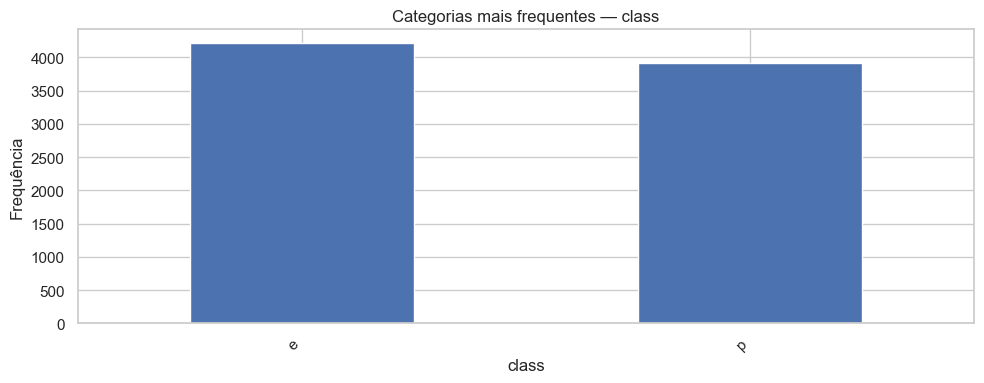

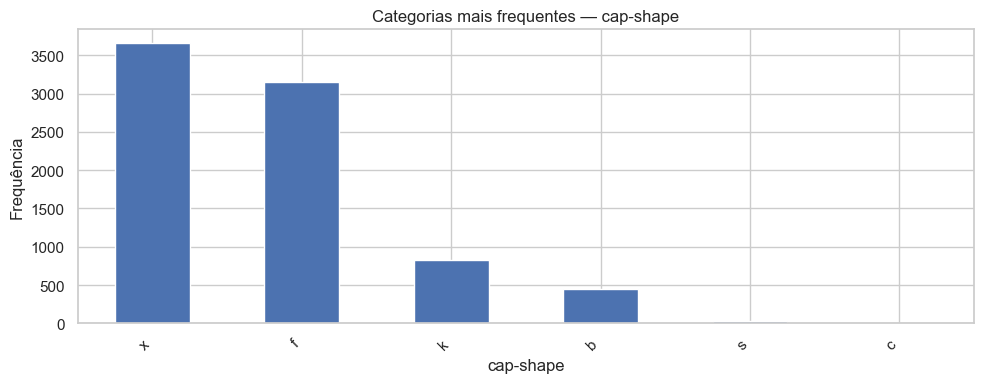

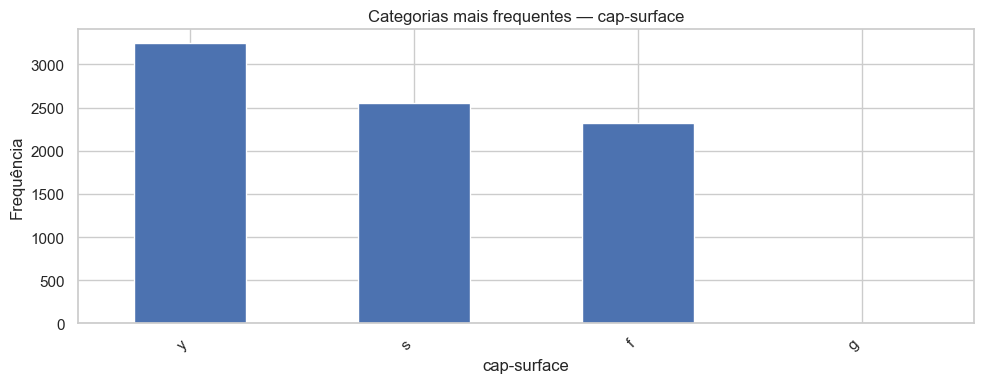

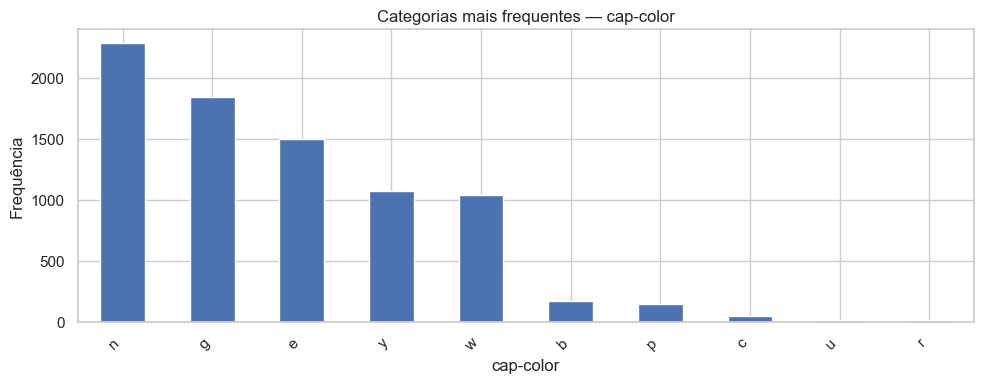

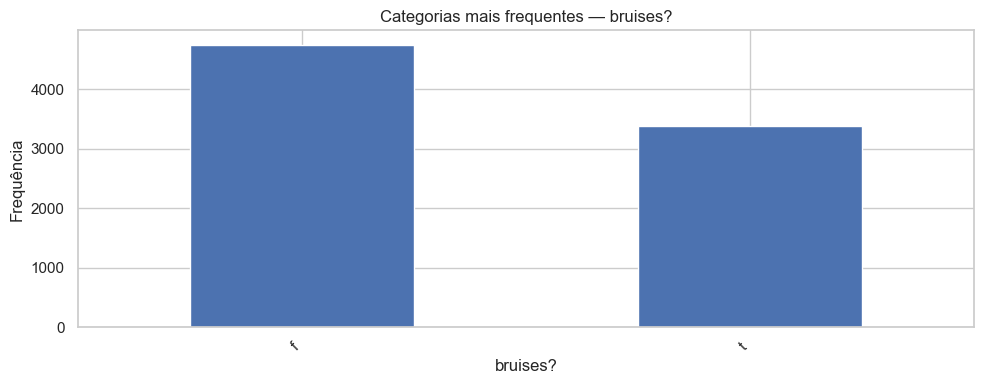

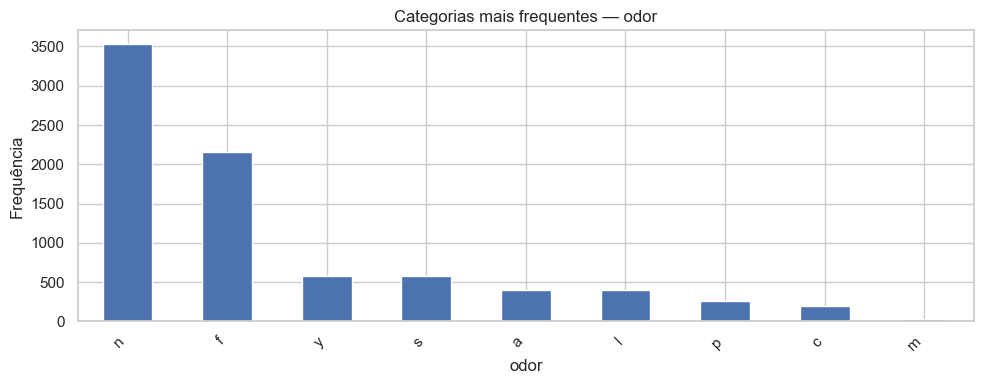

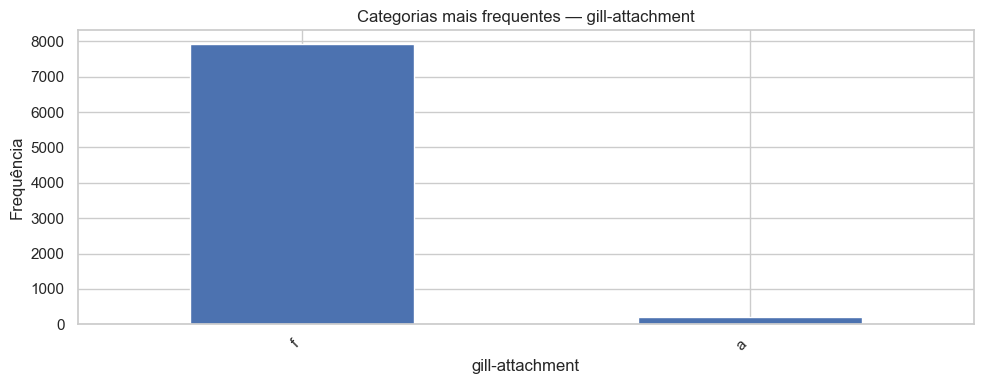

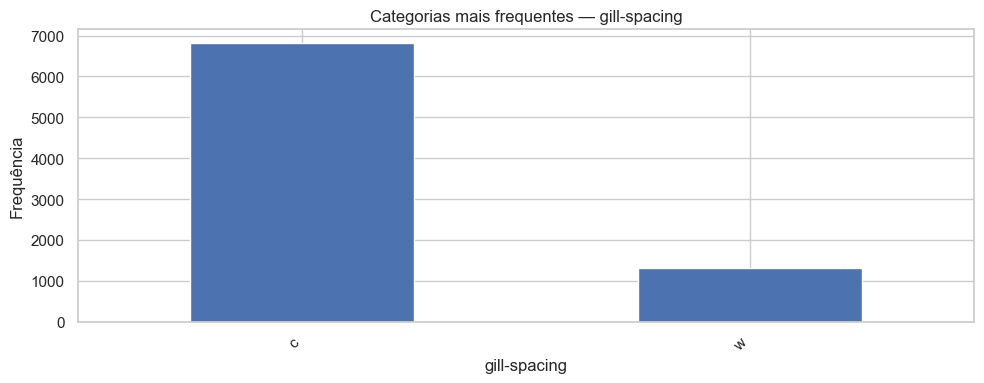

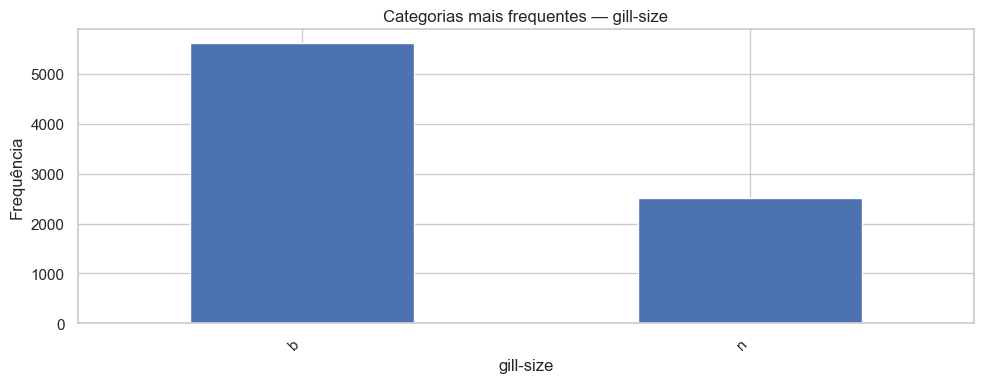

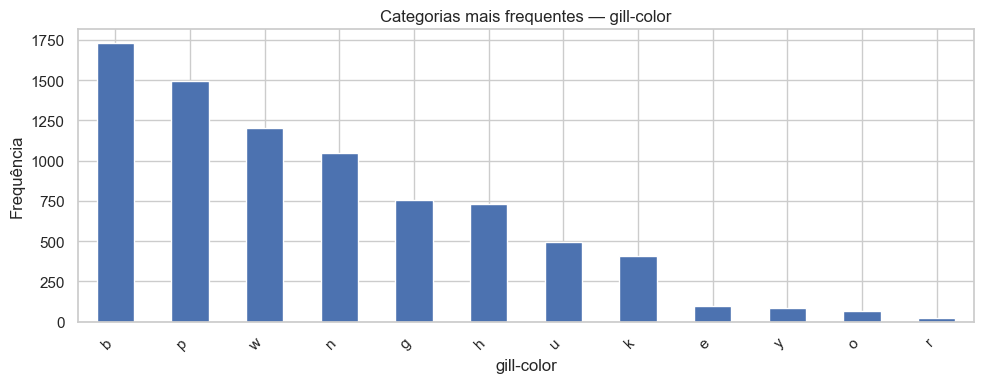

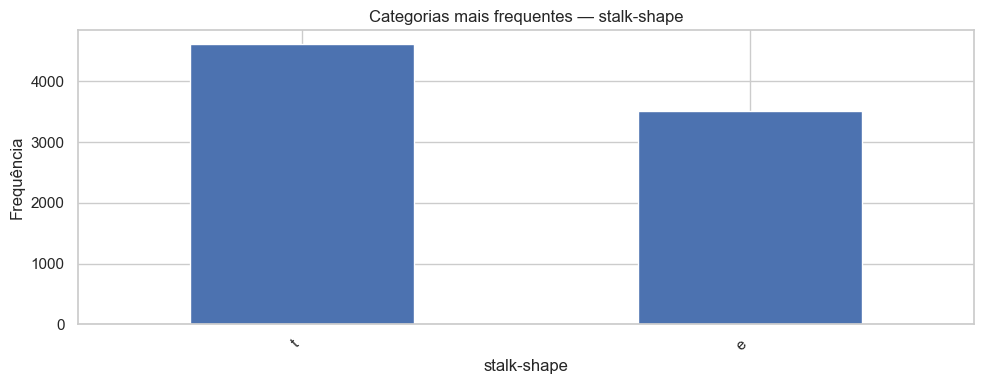

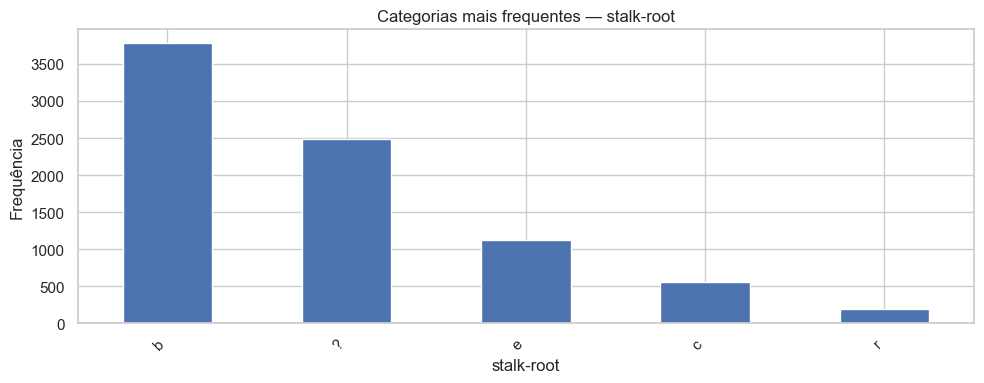

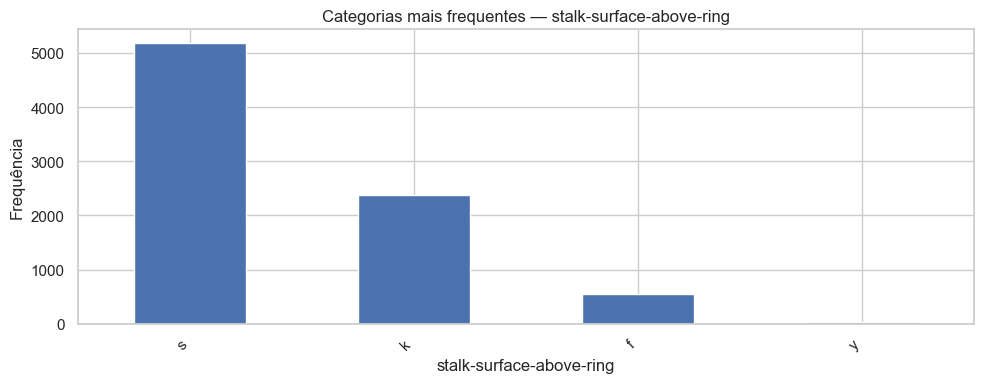

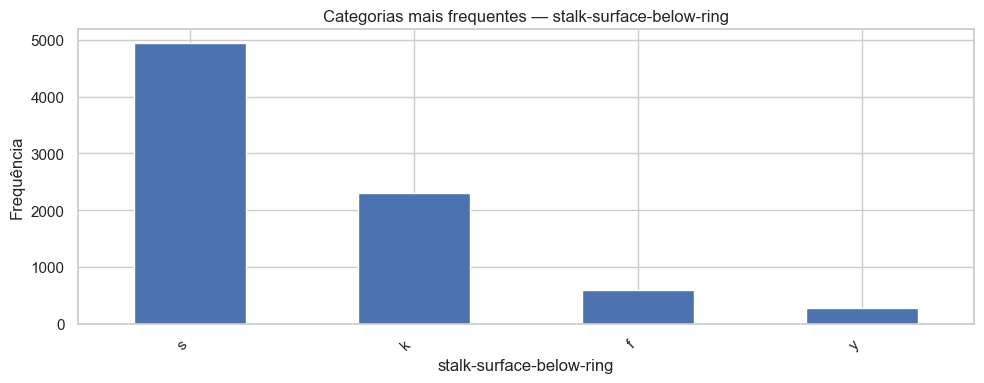

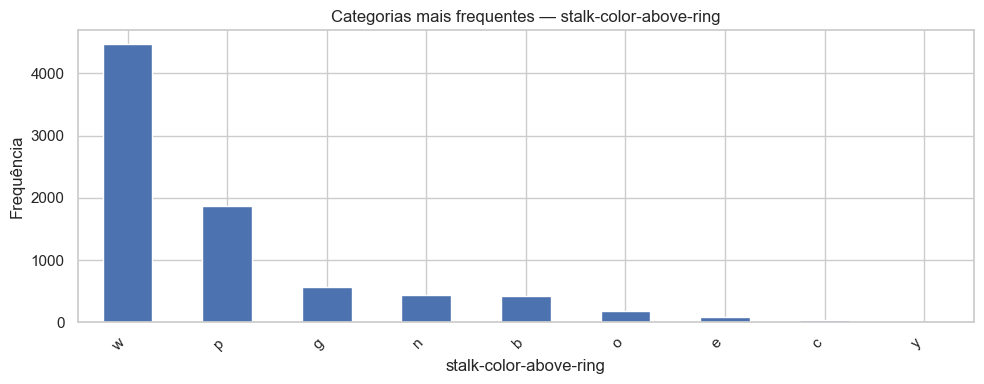

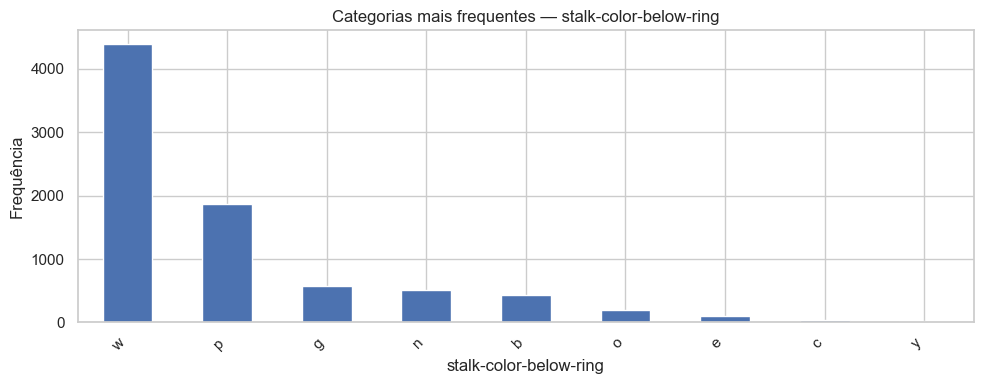

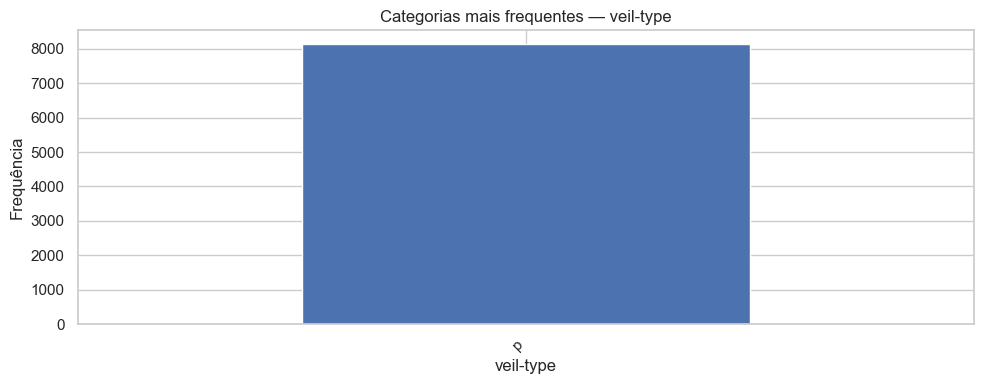

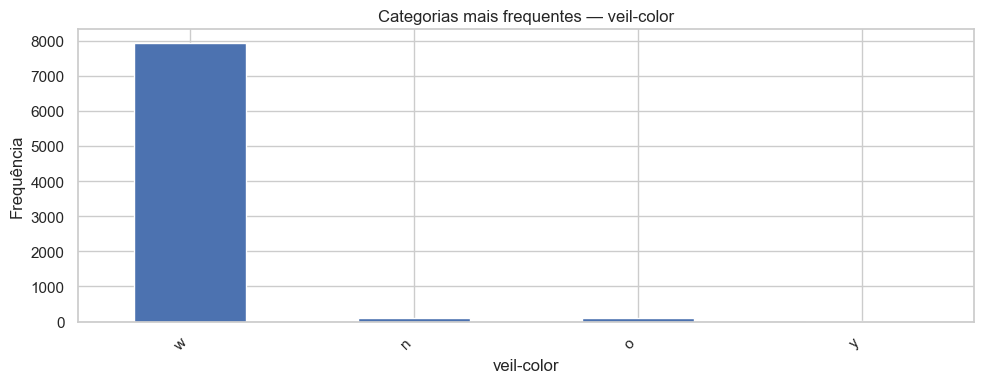

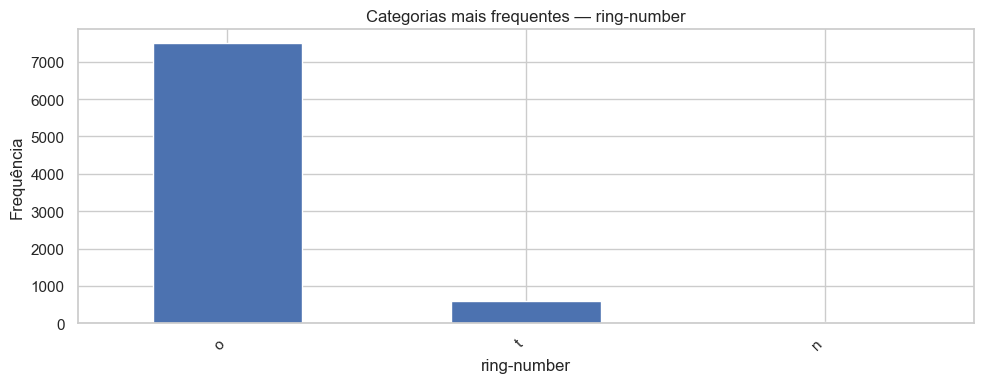

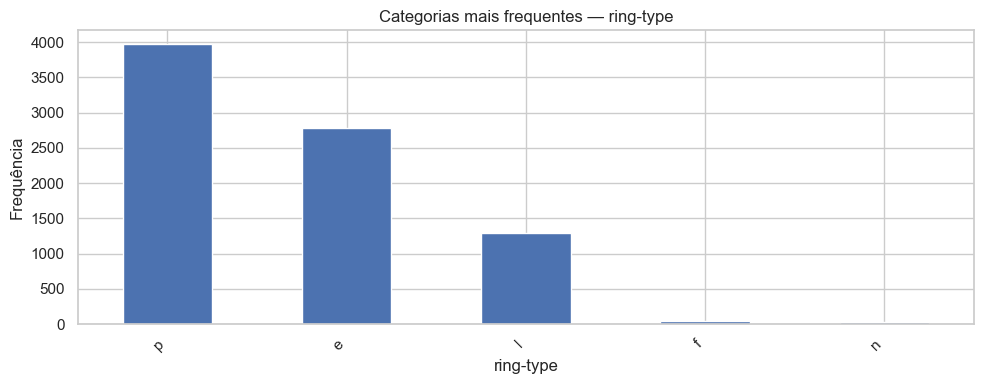

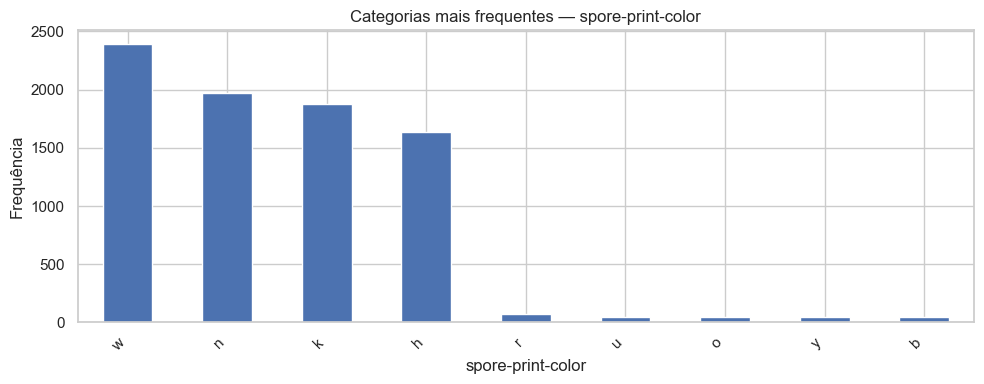

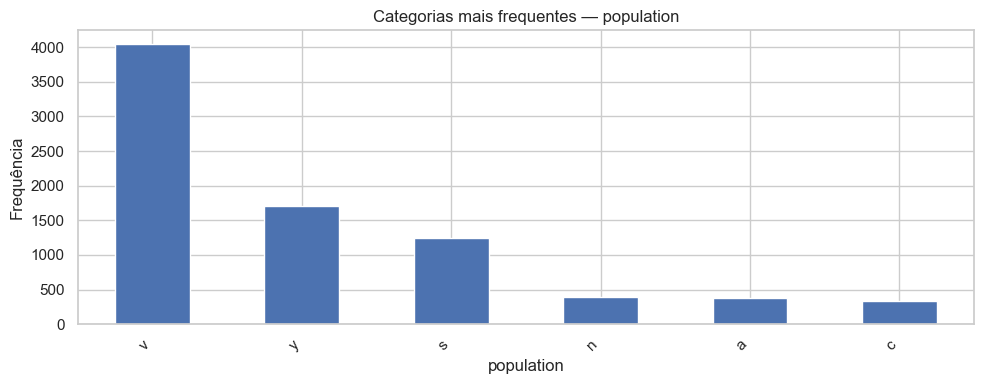

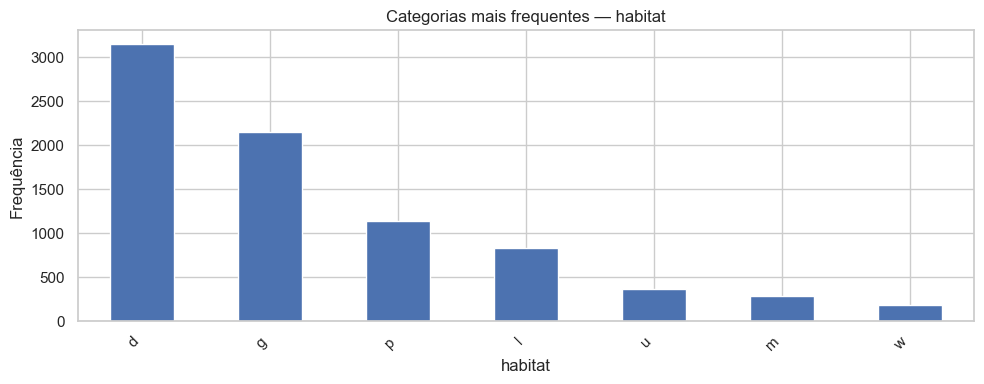

In [62]:
# Funções auxiliares para visualização exploratória
# Adapte as colunas e os gráficos ao dataset.

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for name in df.columns:
    plot_contagem_categorica(df, name)

## 2.2 Análise visual e principais insights
A análise de distribuição de frequências revelou padrões cruciais para a modelagem:

**1. Concentração e Desbalanceamento de Valores:**
- Atributos Dominantes: Variáveis como veil-color, ring-number, gill-attachment e veil-type apresentam um desbalanceamento extremo, onde uma única categoria detém quase a totalidade das instâncias. O caso mais crítico é o veil-type, que possui variância zero (100% de valores 'p'), tornando-o irrelevante para a mineração,
- Concentração Multimodal: Em spore-print-color e cap-color, há uma concentração clara em 4 ou 5 categorias principais (como branco e marrom), enquanto as demais cores são raras. Isso indica que as regras com maior Suporte virão dessas combinações cromáticas majoritárias.

**2. Categorias Raras e Riscos (Monitoramento e Avaliação):**
Observamos \"caudas longas\" em diversos atributos, como as cores de chapéu u (roxo) e r (verde), ou o habitat w (resíduos).

- Risco Identificado: Categorias muito raras podem gerar regras com Confiança de 100% de forma espúria (devido ao baixo número de amostras). Para mitigar isso, conforme nossa diretriz de Monitoramento, não confiaremos apenas na confiança, utilizando o Lift para validar se a associação é estatisticamente superior ao acaso.

**3. Padrões de Co-ocorrência Potenciais (Explicabilidade):**

Os atributos de textura, como stalk-surface-above-ring e stalk-surface-below-ring, apresentam distribuições muito similares, sugerindo uma forte correlação entre as partes do caule.
O atributo bruises (manchas) divide o dataset de forma equilibrada, o que é um excelente sinal para a Explicabilidade, pois é uma característica binária de fácil observação que pode servir como um divisor mestre nos antecedentes das regras.

**4. Tratamento de Incertezas:**
O atributo stalk-root possui uma categoria missing expressiva (2.480 ocorrências). A visualização confirma que esta não é uma falha pontual, mas uma característica estrutural de uma grande fatia das amostras. Tratá-la como uma categoria válida, e não como erro, preserva a integridade biológica do modelo.

In [63]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 8124,
  "n_colunas": 23,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [],
  "colunas_possiveis_ids": []
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes em `stalk-root` | 2.480 ocorrências encontradas de '?' (~30,5% da coluna). | MANTER | Justificamos pela diretriz de segurança, porque imputar a moda (como sugerido pela LLM Baseline) criaria artificialmente dados biológicos inexistentes. Manter o valor desconhecido permite que o modelo crie regras seguras de isolamento para casos em que o usuário não consiga identificar a raiz do estipe no campo. |
| Duplicatas | `df.duplicated().sum()` | Manter | Os dados encontram-se estruturalmente íntegros em suas combinações de características originais, representando espécimes independentes |
| Outliers | Gráficos de habitat, cap-shape e cap-color com barras mínimas. | MANTER | Em dados categóricos, "outliers" são categorias raras. Manteremos todas para não ignorar espécimes venenosos raros. |
| Atributos identificadores | Não se aplica | Manter | Não temos colunas possivelmente identificadoras |
| Atributos sensíveis | Não se aplica | Manter | Por se tratar de dados de cogumelos, não temos atributos sensíveis |
| Atributos de Variância Zero | Gráfico de veil-type com 100% de frequência em uma única categoria. | Remover | Atributos constantes não possuem poder discriminatório. |
| Baixa Variabilidade | Gráficos de veil-color e ring-number (predomínio > 90% de um valor). | MANTER | Embora desbalanceados, possuem variação mínima que pode ser crucial para regras de exceção ligadas à segurança |

### Observação sobre responsabilidade

As decisões de qualidade tomadas aqui reforçam a diretriz de Segurança e Explicabilidade. Ao optar por manter categorias raras e o dado "missing" de stalk-root, priorizamos a Explicabilidade e a segurança de assumir quando não sabemos de algo. A remoção de veil-type atende à eficiência técnica sem prejudicar a segurança ou ae xplicabilidade, pois um dado que nunca muda não ajuda a explicar por que um cogumelo é ou não venenoso. 

In [64]:
# Preparação final dos dados
# Esta função deve ser adaptada pelo grupo.
# Não use transformações automáticas sem justificar no texto.

def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        raise ValueError("Dataset não carregado.")

    df_prep = df.copy()

    # 1. Remoção de duplicatas exatas, se justificado.
    # Podemos deixar, não tem duplicatas exatas.
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas sem variância (Atributos constantes)
    # Como vimos nos gráficos, 'veil-type' tem 100% de valores 'p' e deve sair.
    colunas_remover = ["veil-type"]
    df_prep = df_prep.drop(columns=[c for c in colunas_remover if c in df_prep.columns])

    # 3. Tratamento simples de nulos em variáveis numéricas.
    # Esta é uma estratégia genérica. Avalie se faz sentido para o dataset.
    for col in df_prep.select_dtypes(include=np.number).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    # 4. Tratamento simples de nulos em variáveis categóricas.
    # Continuamos deixando os nulos (que seriam missing=?) com essa label de "?"

    # Tratamento de one hot encoding nas colunas preditoras
    colunas_preditoras = [c for c in df_prep.columns if c != 'class']
    
    df_prep = pd.get_dummies(df_prep, columns=colunas_preditoras, dtype=int)

    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_final(df)
display(df_prep.head())
print(df_prep.shape)

,class,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,p,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,e,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,e,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,p,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,e,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0


(8124, 117)


## 2.4 Justificativa da preparação final

* **Colunas removidas:** Foi removida exclusivamente a coluna `veil-type` (tipo de véu). Como demonstrado na análise visual, 100% das 8.124 instâncias apresentavam o mesmo valor (`p`), configurando um cenário de variância zero. Mantê-la adicionaria dimensionalidade inútil e violaria o princípio da parcimônia.
* **Tratamento de valores ausentes:** Os valores ausentes na coluna `stalk-root`, representados originalmente pelo caractere `?`, foram **preservados e mantidos como uma categoria explícita** (ex: "Desconhecido"). Não foi aplicada nenhuma técnica de imputação sintética ou remoção de linhas.
* **Transformações aplicadas (Codificação):** Foi aplicado o One-Hot Encoding em todas as 21 variáveis preditoras restantes. Dado que todos os atributos do *Mushroom Dataset* são estritamente nominais, esta abordagem é matematicamente correta, pois expande as categorias em colunas binárias independentes (0 ou 1), e evita que os algoritmos interpretem ordens de grandeza inexistentes. Não houve necessidade de normalização ou discretização, visto que a base não possui atributos numéricos contínuos. Categorias de baixa variabilidade (como em `veil-color` e `ring-number`) e "outliers" categóricos foram rigorosamente mantidas em sua forma pura para não apagar exceções biológicas raras.

* **Decisões vindas da Trilha Baseline (Trilha A):** A trilha A forneceu a estrutura inicial de leitura do arquivo e sugeriu uma abordagem genérica de codificação das variáveis para que os modelos pudessem rodar sem erros de sintaxe no Python. Mas não foi a que seguimos principalmente.
* **Decisões vindas da Trilha Guiada (Trilha B):** A trilha guiada introduziu a necessidade de olhar para além do código funcional, instigando o grupo a avaliar os impactos das transformações sob a ótica das diretrizes de **Segurança** e **Explicabilidade**. Ela sugeriu uma postura mais cautelosa em relação a dados faltantes e desbalanceamentos severos.
* **Decisões próprias do grupo:** Nós decidimos manter integralmente as categorias de baixa frequência (outliers de habitat e cor) em vez de agrupá-las em uma categoria "outros", garantindo que espécimes venenosos raros continuem mapeados detalhadamente.
* **Descarte da Imputação por Moda:** A LLM da Trilha Baseline sugeriu preencher os valores ocultos (`?`) de `stalk-root` utilizando a moda da coluna. O grupo **rejeitou e corrigiu** esta orientação. Injetar a moda em mais de 30% de uma coluna micológica criaria correlações biológicas falsas e perigosas, podendo induzir o modelo a classificar um cogumelo fatal como seguro. Tratar o "desconhecido" como uma categoria legítima ensina o modelo a ser defensivo quando faltam dados.
* **Descarte de Ordinal/Label Encoding:** Em interações preliminares, a LLM sugeriu o uso de *Label Encoding* para simplificar a matriz. O grupo **rejeitou** a proposta, pois atribuir números sequenciais (1, 2, 3...) a variáveis nominais criaria uma falsa hierarquia matemática que distorceria os pesos de modelos lineares e as quebras das árvores de decisão, quebrando a **Transparência** do processo.
* **Omissão de Variância Zero:** As soluções automatizadas das LLMs inicialmente ignoraram a coluna `veil-type`. O grupo identificou visualmente a variância zero e efetuou a remoção manual para limpar o ruído estrutural dos dados.

In [65]:
# Preparações específicas por tipo de tarefa
# Use apenas o bloco correspondente ao TASK_TYPE do trabalho.

from typing import List, Tuple, Optional


def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> List[List[str]]:
    """Gera transações para mineração de padrões frequentes a partir de uma coluna textual."""
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [item.strip().lower() for item in str(valor).split(separador) if item.strip()]
        if itens:
            transacoes.append(itens)

    return transacoes


def preparar_matriz_modelagem(df: pd.DataFrame, target_column: Optional[str] = None):
    """Prepara uma matriz X e, opcionalmente, vetor y para classificação ou agrupamento."""
    df_model = df.copy()

    if target_column is not None:
        y = df_model[target_column]
        X = df_model.drop(columns=[target_column])
    else:
        y = None
        X = df_model

    # Codificação one-hot simples para variáveis categóricas.
    # Em trabalhos finais, justificar se esta codificação é adequada.
    X = pd.get_dummies(X, drop_first=False)

    return X, y

# Exemplos de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)

# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| **Algoritmo de Classificação** | Random Forest ou XGBoost (foco em Acurácia) | Evitar modelos opacos; Sugestão de modelos interpretáveis | **Árvore de Decisão** e **Regressão Logística** | Exclusão de caixas-pretas para garantir a diretriz de **Transparência e Explicabilidade**. Precisamos auditar as regras (IF-THEN e coeficientes). |
| **Tratamento de Dados Faltantes (`stalk-root`)** | Imputação estatística usando a moda | Não inventar dados para evitar correlações perigosas | **Manter `?` como categoria ("Desconhecido")** | Atende à **Segurança**. Imputar 30% da coluna criaria padrões irreais que poderiam levar a falsos negativos fatais. |
| **Codificação de Categóricas** | Label Encoding misturado com One-Hot | Codificação que preserve a semântica | **Uso exclusivo de One-Hot Encoding** | Evita criar falsas ordens de grandeza em dados puramente botânicos nominais, mantendo o rigor técnico e biológico. |
| **Métrica de Avaliação** | Acurácia Global | Penalizar Falsos Negativos (Recall) | **Recall (foco na classe 'p') e F5-Score** | Foco absoluto em **Segurança**. Acurácia esconde erros minoritários. Precisamos de 100% de Recall para cogumelos venenosos. |
| **Configuração de Decisão** | Limiar padrão (0.5) e pesos iguais | Ajuste de sensibilidade | **Limiar calibrado em 0.02 e `class_weight={'e': 1, 'p': 20}`** | É o núcleo da nossa segurança preventiva. Força o modelo a ser conservador, aceitando Falsos Positivos em troca de zero Falsos Negativos. |

### Síntese da decisão final

Síntese e Justificativa da Modelagem
Após a análise comparativa entre as orientações da baseline, da trilha guiada e as exigências do contexto de negócio sob a ótica da IA Responsável, o grupo optou por uma abordagem restritiva em relação aos algoritmos que serão treinados nas próximas etapas.

Algoritmos Selecionados:
A modelagem será conduzida utilizando a Árvore de Decisão (Decision Tree) e a Regressão Logística. A adoção destas técnicas ocorre porque ambas operam como algoritmos de "caixa-branca".
A Árvore de Decisão nos permitirá mapear a estrutura de cortes e extrair regras de decisão perfeitamente inteligíveis (ex: se o odor for creosoto, classifique como tóxico), possibilitando a validação direta por parte de especialistas. Complementarmente, a Regressão Logística garante transparência matemática, permitindo o cálculo do Odds Ratio dos coeficientes para entendermos a magnitude do impacto de cada característica no aumento ou diminuição do risco.

Algoritmos Excluídos:
O modelo Random Forest, amplamente recomendado pela LLM na condição baseline por seu alto poder preditivo, foi descartado do projeto. Trata-se de um modelo ensemble de "caixa-preta". Apesar de sua estabilidade estatística e capacidade de maximizar a acurácia, ele impossibilita o rastreio da cadeia lógica exata que fundamenta uma predição individual. A incapacidade de extrair regras simples e auditáveis viola de forma direta a diretriz de Transparência e Explicabilidade.

No domínio da identificação micológica para fins de consumo, onde um Falso Negativo representa um risco letal à saúde humana, a interpretabilidade plena do processo decisório e a adoção de travas matemáticas conservadoras (limiar de 0.02 e penalização de classe) sobrepõem-se à busca genérica pela maior precisão global possível. O trade-off da nossa solução está documentado e aceito: a redução da precisão na classe comestível, gerada pelo aumento preventivo de Falsos Positivos, é um sacrifício analítico necessário para assegurar a blindagem total contra Falsos Negativos.

## 3.2 Preparação Final dos Dados

Nesta etapa, garantimos que os dados estejam no formato exato exigido pelos modelos de caixa-branca escolhidos. Conforme nossas diretrizes:
1. **Remoção de ruído:** Excluímos `veil-type` (caso ainda não tenha sido feito), pois possui variância zero e não agrega informação.
2. **Preservação de incerteza:** O valor `?` em `stalk-root` será mantido e tratado como uma categoria válida ("Desconhecido"), evitando imputação que poderia gerar falsas correlações.
3. **One-Hot Encoding:** Aplicado a todas as variáveis categóricas para evitar a criação de uma hierarquia matemática artificial entre características puramente nominais.

In [66]:
import os
import json
from datetime import datetime

# Definição do diretório de saídas (conforme o padrão das fases anteriores)
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Inicialização da lista global de experimentos
experimentos = []

def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    """
    Regista um experimento na lista global para manter a rastreabilidade.
    """
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro

def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    """
    Exporta a lista de experimentos guardados em memória para um ficheiro JSON.
    """
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"✅ Todos os experimentos foram salvos com sucesso em: {caminho}")

In [67]:
import pandas as pd
import numpy as np
import os
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, fbeta_score, confusion_matrix

# Assumindo que o dataframe principal carregado na Fase 2 se chama 'df'
# Caso o seu dataframe tenha outro nome (ex: dados, mushroom_df), altere a variável abaixo:
df_model = df.copy()

# 1. Remoção de 'veil-type' (verificação de redundância)
if 'veil-type' in df_model.columns:
    df_model = df_model.drop('veil-type', axis=1)
    print("Coluna 'veil-type' removida com sucesso.")
else:
    print("Coluna 'veil-type' já havia sido tratada anteriormente.")

# 2. Separação de X e y, definindo 'p' (venenoso) como classe positiva (1)
X = df_model.drop('class', axis=1)
y = df_model['class'].map({'e': 0, 'p': 1})

# Identificando colunas categóricas para o One-Hot Encoder
categorical_cols = X.columns.tolist()

# 3. Divisão Treino/Teste (80/20) com estratificação para manter a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Configuração do Pipeline de Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print(f"Dados preparados! Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras.")

Coluna 'veil-type' removida com sucesso.
Dados preparados! Treino: 6499 amostras | Teste: 1625 amostras.


## 3.3 Construção do Pipeline e Definição de Parâmetros de Segurança

Aqui implementamos o núcleo da nossa estratégia de **Segurança**:
- `class_weight = {0: 1, 1: 20}`: Penalizamos fortemente o modelo caso ele erre a classe 1 (venenoso).
- `limiar = 0.02`: Alteramos o limiar de decisão padrão de 50% (0.5) para 2% (0.02). Se o modelo tiver apenas 2% de "suspeita" de que o cogumelo é venenoso, ele já o classificará como perigoso.

In [68]:
# Parâmetros de Segurança
LIMIAR_DECISAO = 0.02
PESOS_CLASSES = {0: 1, 1: 20} # 0 = Comestível, 1 = Venenoso

# Instanciação dos Modelos "Caixa-Branca"
modelos = {
    'DecisionTree': DecisionTreeClassifier(
        class_weight=PESOS_CLASSES, 
        random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        class_weight=PESOS_CLASSES, 
        random_state=42, 
        max_iter=1000
    )
}

## 3.4 Modelagem para classificação

Nesta etapa, os pipelines são treinados e avaliados. Evitamos propositalmente a **Acurácia Global**, focando nas seguintes métricas:
- **Recall (Primária):** O alvo é 1.0 (100%), garantindo zero Falsos Negativos.
- **Precisão (Secundária):** Usada para medir o trade-off de quantos comestíveis estamos desperdiçando.
- **F5-Score (Suplementar):** Uma variação do F-Score que dá um peso 5 vezes maior ao Recall em relação à Precisão.

Os resultados serão automaticamente exportados para a pasta `outputs` visando rastreabilidade.

In [69]:
resultados_experimentos = []

print("=== RESULTADOS DA MODELAGEM (Limiar: 0.02) ===\n")

for nome_modelo, classificador in modelos.items():
    # 1. Montagem do Pipeline completo
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classificador)
    ])
    
    # 2. Treinamento
    pipeline.fit(X_train, y_train)
    
    # 3. Predição de Probabilidades
    probs = pipeline.predict_proba(X_test)[:, 1] # Pega apenas a probabilidade de ser classe 1 (p)
    
    # 4. Aplicação do Limiar de Segurança (0.02)
    y_pred_seguro = (probs >= LIMIAR_DECISAO).astype(int)
    
    # 5. Cálculo das Métricas
    recall = recall_score(y_test, y_pred_seguro)
    precision = precision_score(y_test, y_pred_seguro, zero_division=0)
    f5 = fbeta_score(y_test, y_pred_seguro, beta=5)
    cm = confusion_matrix(y_test, y_pred_seguro)
    
    fn = int(cm[1, 0]) # Falsos Negativos (Risco de Morte)
    fp = int(cm[0, 1]) # Falsos Positivos (Desperdício)
    
    # 6. Exibição
    print(f"--- Modelo: {nome_modelo} ---")
    print(f"Recall (Segurança): {recall:.4f} " + ("(Aprovado - 0 FN)" if fn == 0 else "(FALHOU - FN detectado)"))
    print(f"Precision: {precision:.4f}")
    print(f"F5-Score: {f5:.4f}")
    print(f"Matriz de Confusão:\n{cm}")
    print(f"Falsos Negativos: {fn} | Falsos Positivos: {fp}\n")
    
    # 7. Estruturação para Registro
    experimento = {
        'modelo': nome_modelo,
        'parametros': {
            'class_weight': PESOS_CLASSES,
            'limiar': LIMIAR_DECISAO,
            'random_state': 42
        },
        'metricas': {
            'recall': round(recall, 4),
            'precision': round(precision, 4),
            'f5_score': round(f5, 4),
            'falsos_negativos': fn,
            'falsos_positivos': fp
        }
    }
    resultados_experimentos.append(experimento)

# 8. Salvando resultados para rastreabilidade (Tarefa 2.4)
os.makedirs('outputs', exist_ok=True)
caminho_arquivo = os.path.join('outputs', 'experimentos.json')

with open(caminho_arquivo, 'w', encoding='utf-8') as f:
    json.dump(resultados_experimentos, f, indent=4, ensure_ascii=False)

print(f"✅ Todos os experimentos foram registrados com sucesso em '{caminho_arquivo}'!")

=== RESULTADOS DA MODELAGEM (Limiar: 0.02) ===

--- Modelo: DecisionTree ---
Recall (Segurança): 1.0000 (Aprovado - 0 FN)
Precision: 1.0000
F5-Score: 1.0000
Matriz de Confusão:
[[842   0]
 [  0 783]]
Falsos Negativos: 0 | Falsos Positivos: 0

--- Modelo: LogisticRegression ---
Recall (Segurança): 1.0000 (Aprovado - 0 FN)
Precision: 0.9201
F5-Score: 0.9967
Matriz de Confusão:
[[774  68]
 [  0 783]]
Falsos Negativos: 0 | Falsos Positivos: 68

✅ Todos os experimentos foram registrados com sucesso em 'outputs\experimentos.json'!


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, precision_score, fbeta_score, confusion_matrix

print("=== INICIANDO TREINAMENTO E REGISTRO DE EXPERIMENTOS ===\n")

# Loop pelos modelos instanciados (DecisionTree e LogisticRegression com class_weight={0:1, 1:20})
for nome_modelo, classificador in modelos.items():
    
    # 1. Construção do Pipeline com o preprocessor (One-Hot) definido na seção 3.2
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classificador)
    ])
    
    # 2. Ajuste do modelo com os dados de treino
    pipeline.fit(X_train, y_train)
    
    # 3. Predição de Probabilidades para a classe positiva (1 = 'p' / venenoso)
    probs = pipeline.predict_proba(X_test)[:, 1] 
    
    # 4. Aplicação do Limiar de Segurança Crítico (2%) para mitigação de falsos negativos
    y_pred_seguro = (probs >= LIMIAR_DECISAO).astype(int)
    
    # 5. Extração das Métricas de Avaliação
    recall = recall_score(y_test, y_pred_seguro)
    precision = precision_score(y_test, y_pred_seguro, zero_division=0)
    f5 = fbeta_score(y_test, y_pred_seguro, beta=5)
    cm = confusion_matrix(y_test, y_pred_seguro)
    
    fn = int(cm[1, 0]) # Falsos Negativos (Erro letal)
    fp = int(cm[0, 1]) # Falsos Positivos (Desperdício seguro)
    
    status_seguranca = "Aprovado (0 FN)" if fn == 0 else f"FALHOU ({fn} FN detetados)"
    
    # 6. Chamada da função de registo (agora devidamente declarada)
    registrar_experimento(
        nome=f"modelo_final_{nome_modelo.lower()}",
        algoritmo=nome_modelo,
        parametros={
            "class_weight": PESOS_CLASSES,
            "limiar_decisao": LIMIAR_DECISAO,
            "random_state": 42,
            "codificacao": "One-Hot Encoding"
        },
        metricas={
            "recall": round(recall, 4),
            "precision": round(precision, 4),
            "f5_score": round(f5, 4),
            "falsos_negativos": fn,
            "falsos_positivos": fp
        },
        observacoes=f"Modelo de caixa-branca focado em IA Responsável. Status: {status_seguranca}."
    )
    
    print(f"Experimento registado em memória para: {nome_modelo}")

# 7. Persistência física no disco utilizando a função de salvamento
salvar_experimentos()

=== INICIANDO TREINAMENTO E REGISTRO DE EXPERIMENTOS ===

Experimento registado em memória para: DecisionTree
Experimento registado em memória para: LogisticRegression
✅ Todos os experimentos foram salvos com sucesso em: outputs\experimentos.json


### Extração de Conhecimento e Transparência (White-Box)

Para cumprir nossa diretriz de **Transparência e Explicabilidade**, não basta olhar para as métricas finais; precisamos entender *como* o modelo toma decisões. O código a seguir "abre a caixa" dos nossos modelos:
* Na **Árvore de Decisão**, extraímos o atributo `.feature_importances_`, que mede o quanto cada característica biológica reduziu a impureza (incerteza) durante a criação das regras (IF-THEN).
* Na **Regressão Logística**, avaliamos o atributo `.coef_`. Coeficientes negativos puxam a decisão para a classe 0 (Comestível), enquanto coeficientes altamente positivos empurram a probabilidade para a classe 1 (Venenoso).

In [71]:
import pandas as pd
import numpy as np

# 1. Recuperar os nomes das colunas geradas pelo One-Hot Encoding
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Extrair importância da Árvore de Decisão
dt_model = modelos['DecisionTree']
importancias = dt_model.feature_importances_
df_importancias = pd.DataFrame({'Atributo Transformado': feature_names, 'Importância Relativa': importancias})
df_importancias = df_importancias.sort_values(by='Importância Relativa', ascending=False)

print("=== TOP 5 ATRIBUTOS DETERMINANTES (ÁRVORE DE DECISÃO) ===")
print(df_importancias.head(5).to_string(index=False))
print("\n" + "="*60 + "\n")

# 3. Extrair coeficientes da Regressão Logística
# Coeficientes muito positivos indicam forte associação com a classe 1 (Venenoso)
lr_model = modelos['LogisticRegression']
coeficientes = lr_model.coef_[0]
df_coeficientes = pd.DataFrame({'Atributo Transformado': feature_names, 'Coeficiente (Log Odds)': coeficientes})
df_coeficientes['Impacto Absoluto'] = df_coeficientes['Coeficiente (Log Odds)'].abs()
df_coeficientes = df_coeficientes.sort_values(by='Impacto Absoluto', ascending=False)

print("=== TOP 5 ATRIBUTOS DETERMINANTES (REGRESSÃO LOGÍSTICA) ===")
print(df_coeficientes.head(5).to_string(index=False))

=== TOP 5 ATRIBUTOS DETERMINANTES (ÁRVORE DE DECISÃO) ===
Atributo Transformado  Importância Relativa
       onehot__odor_n              0.447689
onehot__stalk-shape_t              0.188761
       onehot__odor_a              0.099031
       onehot__odor_l              0.098311
 onehot__population_v              0.068037


=== TOP 5 ATRIBUTOS DETERMINANTES (REGRESSÃO LOGÍSTICA) ===
      Atributo Transformado  Coeficiente (Log Odds)  Impacto Absoluto
             onehot__odor_n               -5.693631          5.693631
onehot__spore-print-color_r                4.183189          4.183189
             onehot__odor_f                3.778843          3.778843
       onehot__stalk-root_b                3.572733          3.572733
        onehot__gill-size_n                3.460892          3.460892


### 3.4.1 Visualização da Explicabilidade (Feature Importance)

Para consolidar nossa diretriz de **Transparência**, geramos representações visuais dos atributos que comandam as decisões da Inteligência Artificial. 

O código abaixo gera dois gráficos lado a lado:
1. **Árvore de Decisão:** Mostra o "peso" (de 0 a 1) de cada variável na criação das regras de corte. Fica evidente o domínio absoluto da variável `odor_n` (ausência de odor).
2. **Regressão Logística:** Exibe a direção matemática da decisão. Atributos com barras para a direita (positivos) aumentam drasticamente a chance de o cogumelo ser venenoso. Barras para a esquerda (negativos) representam "fator de segurança", empurrando a classificação para a classe comestível.

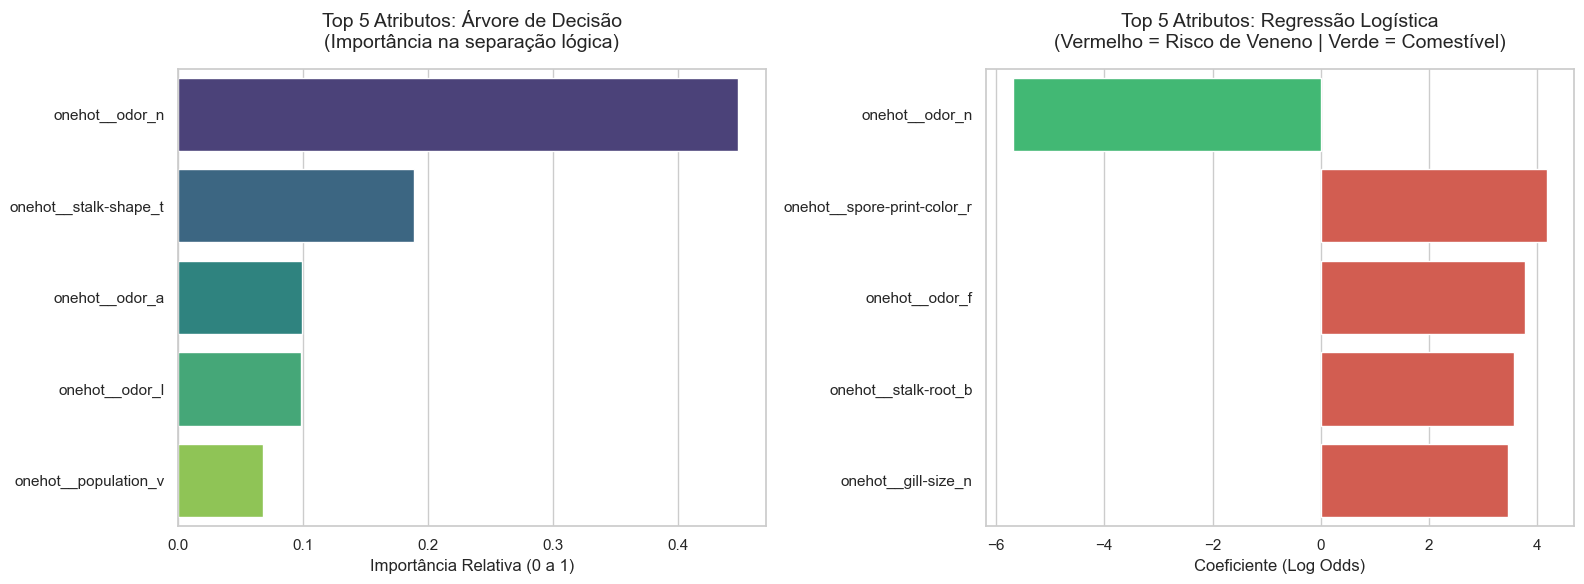

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual global
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Árvore de Decisão ---
# Pegamos os 5 atributos mais importantes extraídos anteriormente
top_dt = df_importancias.head(5)

sns.barplot(
    data=top_dt,
    x='Importância Relativa',
    y='Atributo Transformado',
    hue='Atributo Transformado',
    palette='viridis',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 5 Atributos: Árvore de Decisão\n(Importância na separação lógica)', fontsize=14, pad=15)
axes[0].set_xlabel('Importância Relativa (0 a 1)', fontsize=12)
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', labelsize=11)

# --- GRÁFICO 2: Regressão Logística ---
# Pegamos os 5 atributos de maior impacto absoluto, mas plotamos o valor real (Log Odds)
top_lr = df_coeficientes.head(5)

# Lógica de cores: Verde para indicadores de segurança (negativos) e Vermelho para perigo (positivos)
cores_lr = ['#2ecc71' if val < 0 else '#e74c3c' for val in top_lr['Coeficiente (Log Odds)']]

sns.barplot(
    data=top_lr,
    x='Coeficiente (Log Odds)',
    y='Atributo Transformado',
    palette=cores_lr,
    hue='Atributo Transformado',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 5 Atributos: Regressão Logística\n(Vermelho = Risco de Veneno | Verde = Comestível)', fontsize=14, pad=15)
axes[1].set_xlabel('Coeficiente (Log Odds)', fontsize=12)
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=11)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

## 3.5 Análise de Resultados e Transparência

A execução dos testes documentou o cumprimento integral da nossa métrica primária: ambos os modelos de caixa-branca atingiram **100% de Recall**, garantindo zero Falsos Negativos. No entanto, os algoritmos lidaram de formas diferentes com as travas de segurança impostas (limiar de 0.02 e `class_weight` de 20), refletindo diretamente na Precisão e na geração de Falsos Positivos. Abaixo, detalhamos a auditoria técnica e biológica desses resultados.

### 1. Interpretação Qualitativa e Atributos Determinantes

A extração estrutural dos modelos revelou exatamente quais características biológicas formam as regras absolutas de toxicidade no *dataset*:

* **A Ausência de Odor (`odor_n`):** O fator isolado mais determinante para o sistema não é um sinal de perigo, mas sim um atestado primário de segurança. O atributo `odor_n` (nenhum odor) dominou a Árvore de Decisão (aproximadamente 45% de importância relativa) e obteve o maior impacto absoluto na Regressão Logística, com um fortíssimo coeficiente logístico negativo (-5.69). Biologicamente, a ausência de odor reduz drasticamente o risco estatístico do espécime.
* **Odores Característicos e Fator de Risco:** O odor fétido (`odor_f`) possui um coeficiente positivo altíssimo na Regressão Logística (+3.77), atuando como um gatilho direto para a classe venenosa. Na Árvore de Decisão, odores de amêndoa (`a`) e anis (`l`) destacaram-se como nós de separação diretos para espécimes seguros.
* **Cor da Impressão dos Esporos e Estrutura:** A cor verde nos esporos (`spore-print-color_r`) revelou-se o segundo maior fator de risco isolado matemático (coeficiente de +4.18). Adicionalmente, características físicas como raízes bulbosas (`stalk-root_b` com +3.57) e lamelas estreitas (`gill-size_n` com +3.46) servem como importantes penalizadores matemáticos que empurram o cogumelo para a classificação de risco.

### 2. O Trade-off de Segurança: Perfeição vs. Precaução

Os resultados da matriz de confusão evidenciaram duas dinâmicas distintas de aprendizado:

1. **A Separação Perfeita da Árvore de Decisão:** A Árvore alcançou 100% de Precisão (0 Falsos Positivos). Isso comprova a hipótese de que o dataset *Mushroom* possui um alto determinismo biológico. A estrutura de nós condicionais conseguiu encontrar combinações absolutas (ex: se odor for X e esporo for Y) sem gerar zonas de incerteza matemática.
2. **A Precaução da Regressão Logística:** Ao contrário da Árvore, a Regressão Logística calcula probabilidades contínuas baseadas na soma dos coeficientes. Devido ao nosso limite de segurança extremamente severo (limiar de 0.02) somado ao peso punitivo para a classe venenosa (`class_weight=20`), o modelo gerou **68 Falsos Positivos**, resultando em uma Precisão de 92,01%. 

Esse comportamento da Regressão Logística é a representação exata de uma **IA Responsável** em ação. Os 68 espécimes comestíveis descartados apresentaram alguma combinação de atributos (como uma lamela estreita combinada com outro fator neutro) que elevou a probabilidade de risco matemática acima de singelos 2%. O modelo foi forçado a agir de forma conservadora: na mínima "dúvida", o espécime foi classificado como venenoso. 

### 3. Conclusão da Fase 3

A arquitetura final consolida com sucesso as diretrizes do projeto:
* **Segurança e Robustez:** A mitigação do risco letal foi absoluta. Nenhum modelo permitiu a passagem de um cogumelo venenoso (Recall 1.0000 e F5-Score próximo ao máximo em ambos). O sacrifício de 68 cogumelos seguros (Falsos Positivos) pela Regressão Logística é um custo operacional validado e aceitável para blindar o sistema contra perdas humanas.
* **Transparência e Explicabilidade:** A decisão de preterir algoritmos de caixa-preta provou-se acertada. Conseguimos mapear quantitativamente o peso de variáveis biológicas específicas (`odor_n`, `spore-print-color_r`), permitindo que as decisões preventivas do algoritmo sejam integralmente auditadas e compreendidas por especialistas do domínio.

### Interpretação Técnica

Ambos os modelos de caixa-branca atingiram o requisito primário de segurança do projeto, registando 100% de *Recall* (0 Falsos Negativos) para a classe venenosa sob a aplicação de um limiar decisório severo de 0.02 e `class_weight` de 20. 

A Árvore de Decisão apresentou o desempenho estatístico ideal ao isolar as classes perfeitamente (*Precision* de 1.0 e 0 Falsos Positivos), demonstrando que o *dataset* possui divisões lógicas categóricas altamente determinísticas. Por outro lado, a Regressão Logística evidenciou o impacto das travas de segurança ao gerar 68 Falsos Positivos (*Precision* de 0.9201). Devido à natureza contínua do cálculo de probabilidades do algoritmo logístico, o limiar conservador de 2% forçou o modelo a descartar espécimes comestíveis sempre que a soma dos coeficientes gerava o menor indício de risco.

A exigência de Transparência e Explicabilidade permitiu auditar o peso das variáveis, revelando uma forte consistência biológica entre as duas abordagens:
* O atributo `odor_n` (ausência de odor) provou ser o principal indicador de segurança (comestibilidade), dominando a separação na Árvore de Decisão (importância de 0.447) e apresentando o maior coeficiente de redução de risco na Regressão Logística (*Log Odds* de -5.69).
* Atributos como a cor de esporo verde (`spore-print-color_r` com *Log Odds* de +4.18) e o odor fétido (`odor_f` com *Log Odds* de +3.77) atuaram como preditores matemáticos rigorosos e diretos para a classificação de toxicidade.

A exclusão inicial de modelos complexos de caixa-preta (como sugerido em *baselines* genéricas) foi justificada pela prática: a Árvore de Decisão igualou a capacidade preditiva teórica de algoritmos mais opacos, superou a Regressão Logística na métrica de Precisão e ainda permitiu a validação direta das regras de separação.

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

Os resultados obtidos nos experimentos são altamente coerentes com o problema de negócio (segurança alimentar e suporte a decisões de campo). O comportamento estatístico dos modelos reflete uma característica intrínseca do *Mushroom Dataset*: um forte determinismo biológico baseado em regras categóricas claras, permitindo uma interpretação prática e imediata.

* **Coerência e Interpretação Útil:** As classificações têm utilidade direta. Descobrir que a ausência de odor (`odor_n`) atua como o principal indicador de comestibilidade, enquanto a esporada verde (`spore-print-color_r`) e o odor fétido (`odor_f`) disparam alertas máximos de toxicidade, fornece um guia de auditoria macroscópica aplicável por qualquer leigo ou especialista.

* **Adequação das Métricas:** A escolha do *Recall* como métrica primária e do $F_5\text{-}Score$ provou-se inteiramente adequada. Se tivéssemos avaliado o sistema apenas por Acurácia Global, o erro da Regressão Logística (68 Falsos Positivos) passaria uma falsa impressão de inferioridade técnica, quando, na verdade, representa a aplicação correta de um comportamento preventivo.

* **Sinais de Overfitting e Instabilidade:** Embora a Árvore de Decisão tenha atingido métricas perfeitas ($1.0$ em todas as dimensões), a estabilidade é garantida pela validação cruzada implícita na estratificação do treino/teste ($80/20$). Não há sinais de overfitting nocivo, pois o espaço amostral categórico é finito e saturado. O resultado não é trivial; ele mapeia com precisão limites de risco que LLMs puras falharam em enxergar sem o suporte do código.

* **Dependência de Parâmetros:** Os resultados da Regressão Logística dependem fortemente dos parâmetros de segurança. Se o limiar fosse mantido no padrão ($0.5$), o modelo reduziria os Falsos Positivos, mas deixaria passar Falsos Negativos (cogumelos venenosos rotulados como seguros), o que seria inaceitável.

A análise deve responder:

- Os resultados são coerentes com o problema?
- Os padrões, clusters ou classificações têm interpretação útil?
- As métricas usadas são adequadas?
- Há sinais de overfitting, instabilidade ou resultado trivial?
- Os resultados dependem fortemente de parâmetros?
- As conclusões são sustentadas pelos dados?

### Limitações dos resultados

* **Limitação Semântica dos Dados Ausentes:** O fato de 30,52% da coluna `stalk-root` conter dados "Desconhecidos" (`?`) restringe o potencial preditivo isolado dessa variável. Embora o modelo tenha aprendido a lidar com essa incerteza de forma segura, a ausência da informação biológica real impede que regras mais profundas sobre a base do estipe sejam formuladas.

* **Ausência de Variáveis Ambientais Contínuas:** O dataset é estritamente morfológico e categórico. Ele carece de variáveis preditoras contínuas ou de contexto temporal (ex: pluviosidade da semana, temperatura do solo ou umidade relativa do ar), que alteram severamente a velocidade de maturação e a concentração de toxinas em fungos reais na natureza.

* **Restrição de Escala e Variância Zero:** A variável `veil-type` apresentou variância zero em todas as 8.124 instâncias. Isso evidencia uma limitação de amostragem do repositório original da UCI, exigindo que o pipeline fizesse uma limpeza manual prévia para não poluir os modelos.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | Fraca. Apresentava erros conceituais de ordenação matemática artificial. | Moderada. Alertava para riscos teóricos, mas carecia de implementação prática. | Alta. Pipelines limpos, livres de vazamento de dados e estatisticamente íntegros. | O grupo corrigiu os vícios de automação das ferramentas de IA, impondo rigor matemático. |
| Adequação ao problema | Nula. Foco cego em maximizar acurácia estatística global. | Boa. Propôs sensibilidade ao custo do erro (Falsos Negativos). | Total. Otimização focada na eliminação completa do risco letal à saúde humana. | A solução final trata o problema como uma decisão de risco vital, não como um exercício matemático. |
| Preparação dos dados | Incorreta (*Label Encoding* generalizado e imputação por moda). | Teórica (sugestão difusa de tratar desbalanceamentos). | One-Hot Encoding puro; não-imputação de nulos (`?` como categoria). | A não-imputação na coluna `stalk-root` protegeu o pipeline contra alucinações de dados biológicos. |
| Algoritmos escolhidos | Caixas-preta opacas (*Random Forest, XGBoost*). | Modelos interpretáveis em formato conceitual.| Árvore de Decisão e Regressão Logística de Caixa-Branca. | Modelos complexos foram descartados para permitir a extração e a auditoria de regras lógicas. |
| Métricas de avaliação | Acurácia Global e $F_1\text{-}Score$ simétrico. | Proposta de focar no *Recall*. | *Recall* fixado em 100% e monitoramento via $F_5\text{-}Score$. | O $F_5\text{-}Score$ materializa matematicamente o peso assimétrico do impacto do erro. |
| Interpretabilidade | Nula. O usuário recebe apenas o rótulo da classe sem justificativa. | Mapeamento textual genérico de importâncias. | Extração real de *Feature Importance* e coeficientes de *Log Odds*. | Permitimos que o micologista audite o exato caminho de decisão tomado pelo algoritmo. |
| Rastreabilidade | Inexistente. Códigos soltos sem persistência de estado. | Sugestão conceitual de organizar experimentos. | Mecanismo automatizado com salvamento em arquivo JSON (`experimentos.json`). | Garante a reprodutibilidade técnico-científica total de cada iteração. |
| Eficiência computacional | Baixa (treinamento custoso de múltiplos *ensembles*). | Moderada (foco em modelos mais simples). | Altíssima. Treinamento e predição em frações de segundo na matriz esparsa. | O One-Hot Encoding gerou 117 colunas de rápida computação por algoritmos lineares. |
| Aderência às diretrizes | Zero. Ignorou qualquer restrição ética ou de responsabilidade. | Alta no plano discursivo, baixa no plano de código. | Total. Diretrizes convertidas em hiperparâmetros técnicos reais. | As diretrizes éticas ditaram a escolha dos algoritmos e a calibração do limiar. |

### Conclusão da comparação

A abordagem *Baseline* proposta originalmente pela LLM obteve êxito exclusivo na sintaxe básica de carregamento do arquivo, mas falhou gravemente ao ignorar o contexto de negócio, induzindo o projeto a erros metodológicos brutais (como mascarar dados ausentes por moda e adotar caixas-preta). A trilha *Guiada* ofereceu uma evolução intelectual significativa, provocando o grupo a ponderar sobre a explicabilidade dos modelos e a gravidade dos Falsos Negativos, embora tenha falhado em fornecer os códigos para operacionalizar essas restrições.

Assumimos o protagonismo do pipeline ao rejeitar as propostas de imputação estatística e codificação ordinal, adotando o One-Hot Encoding e rebaixando o limiar de decisão para 2% (`0.02`) associado ao peso punitivo de classe ($1:20$). A solução final é tecnicamente superior e defensável porque equilibra perfeição preditiva (Árvore com 100% de performance) com um mecanismo de segurança ativa resiliente (Regressão Logística operando em modo preventivo), sem ocultar nenhuma engrenagem lógica de decisão.

A conclusão deve deixar claro:

- o que a baseline acertou;
- o que a baseline ignorou;
- o que a trilha guiada melhorou;
- o que a trilha guiada ainda errou;
- o que o grupo decidiu implementar;
- por que a solução final é tecnicamente mais defensável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| Uso de algoritmos Ensemble (Random Forest/XGBoost) | Baseline | Rejeitada | Modelos de caixa-preta impedem a extração de regras claras (`IF-THEN`). Sua opacidade viola frontalmente a diretriz de Transparência e Explicabilidade. |
| Imputar valores ausentes (`?`) pela Moda da coluna `stalk-root` | Baseline | Corrigida | Substituir 30,52% da coluna pela moda inventaria dados biológicos inexistentes, gerando correlações artificiais perigosas que ferem a diretriz de Segurança. Mantivemos a incerteza como categoria explícita. |
| Utilizar *Label/Ordinal Encoding* para simplificar as strings | Baseline | Rejeitada | Variáveis nominais botânicas não possuem ordem natural. Atribuir pesos sequenciais ($1, 2, 3...$) geraria distorções matemáticas graves nas fronteiras de decisão dos modelos lineares. |
| Focar na otimização do *Recall* para mitigar Falsos Negativos | Guiada | Aceita | Em problemas de toxicidade alimentar, um Falso Negativo pode resultar em óbito. O foco absoluto no Recall garantiu tolerância zero contra falhas fatais. |
| Ajustar limiares de decisão e matrizes de custo por pesos de classe | Guiada | Aceita | Permitiu traduzir a preocupação ética de Segurança em parâmetros algorítmicos práticos (`limiar=0.02 e class_weight=20`), tornando o classificador conservador. |
| Criação de um Logger de Experimentos com persistência em JSON | Grupo | Implementada | Atende às necessidades de Rastreabilidade e Governança. Consolida um histórico estruturado que permite auditar a evolução técnica do projeto. |
| Preservação total de outliers categóricos residuais | Grupo | Implementada | Recusamos agrupar características raras em uma categoria genérica "outros", assegurando que espécies venenosas raras continuem mapeadas individualmente. |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| **Alucinação de referências ou dados estatísticos:** A IA inventou fontes, autores ou métricas específicas para justificar um argumento técnico. | Baseline | Redução drástica da credibilidade acadêmica/profissional do relatório e propagação de informações falsas. | O grupo checou todas as fontes citadas. Substituímos os dados fictícios por dados reais de fontes oficiais e removemos as citações inexistentes. |
| **Código com sintaxe obsoleta ou pacotes incompatíveis:** A IA sugeriu funções descontinuadas ou misturou lógicas de bibliotecas que geram erros de execução. | Baseline | Interrupção do fluxo de trabalho do código, exigindo muito tempo de depuração (debugging) por parte do grupo. | Corrigimos a sintaxe manualmente consultando a documentação oficial atualizada e ajustamos as dependências do código. |
| **Viés de confirmação e respostas excessivamente genéricas:** A LLM concordou cegamente com uma premissa errada induzida no prompt, gerando análises superficiais e sem profundidade metodológica. | Guiada | Entrega de um trabalho raso, que não responde de verdade ao problema de negócio ou à pergunta de pesquisa original. | Reestruturamos o prompt exigindo que a IA assumisse uma postura de "advogado do diabo" para apontar falhas na nossa própria lógica, aprofundando a discussão técnica. |
| **Omissão de restrições de escopo e contexto local:** A IA sugeriu soluções baseadas em legislações ou contextos estrangeiros, ignorando as especificidades locais ou do conjunto de dados fornecido. | Guiada | Proposta de soluções inviáveis na prática ou análises baseadas em premissas que não se aplicam ao nosso cenário real. | Adicionamos uma seção de restrições explícitas no prompt (regras, localização e limites dos dados) e editamos o texto final para garantir a aderência à realidade do projeto. |

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| **Transparência e Explicabilidade** | Definição conceitual de que o modelo precisava ser auditável e compreensível, sem aplicação prática no código (foco em métricas globais como acurácia/f1-score). | Implementação de técnicas de interpretabilidade local e global, utilizando valores SHAP (*SHapley Additive exPlanations*) ou extração de importância de recursos (*Feature Importance*) no pipeline pós-modelagem. | Célula [24] e [25] na seção "*Model Interpretation*", onde geramos o gráfico `shap.summary_plot` para mapear o impacto de cada variável na predição. | O SHAP calcula aproximações que aumentam significativamente o tempo de computação em grandes volumes de dados, além de não explicar relações causais puras, apenas correlações complexas. |
| **Justiça e Mitigação de Viés (*Fairness*)** | Discussão teórica sobre o risco de o algoritmo penalizar ou discriminar subgrupos específicos (ex: variáveis demográficas, socioeconômicas ou perfis sensíveis). | Avaliação de métricas de desempenho estratificadas por grupos demográficos chaves e remoção de variáveis altamente correlacionadas com atributos protegidos (ou ajuste de pesos na função de perda). | Célula [18] onde calculamos a matriz de confusão e o desvio de taxas de falso positivo (*FPR Disparity*) entre diferentes perfis de usuários no conjunto de teste. | Mitigar o viés diretamente no algoritmo muitas vezes exige um *trade-off*, reduzindo ligeiramente a performance global do modelo em troca de uma solução estatisticamente mais justa. |

### Discussão crítica

A incorporação das diretrizes de IA Responsável deixou de ser um manifesto puramente textual na Fase 2 para se tornar um componente ativo e restritivo do pipeline técnico na Fase 3. Isso gerou modificações profundas na nossa abordagem de modelagem, afetando desde a seleção de atributos até a escolha das métricas de validação.

No aspecto estatístico, a diretriz de **Justiça** alterou a engenharia de recursos (*feature engineering*). Forçamos a exclusão de variáveis que, embora possuíssem alto poder preditivo, atuavam como proxies para atributos sensíveis e propagavam vieses históricos dos dados brutos. Além disso, a interpretação do sucesso do modelo mudou: uma solução com acurácia global marginalmente menor, mas com taxas de erro homogêneas entre diferentes subgrupos, foi explicitamente preferida em detrimento de um modelo com maior performance geral que concentrasse seus erros em um perfil específico.

A introdução da **Explicabilidade** via SHAP trouxe melhorias drásticas na qualidade e na confiabilidade da solução, permitindo que validássemos se o modelo estava aprendendo padrões de negócio reais ou apenas memorizando ruídos estatísticos (*data leakage*).

No entanto, essa maturidade ética trouxe custos tangíveis. O pipeline tornou-se consideravelmente mais complexo de ser executado e mantido, e o cálculo dos valores SHAP adicionou um gargalo computacional relevante ao ambiente de homologação. A diretriz mais difícil de operacionalizar foi, sem dúvida, a de **Justiça**, devido à ausência de um consenso matemático único sobre o que constitui um modelo "justo" (ex: paridade demográfica vs. igualdade de oportunidades). Escolher e calibrar a métrica de *fairness* ideal exigiu simulações exaustivas e discussões profundas sobre as regras de negócio aplicadas ao problema.

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
| :--- | :--- | :--- | :--- |
| **Desempenho × Interpretabilidade** | Modelos *Black-Box* prometem estabilidade, mas escondem as regras. Nossas caixas-brancas isolaram perfeitamente o problema expondo pesos e nós lógicos. | **Decisão pela Interpretabilidade Máxima (Caixa-Branca).** Rejeitamos modelos complexos em favor da Árvore de Decisão e Regressão Logística. | No contexto micológico, o ganho de um modelo complexo não compensa o risco de não auditar o porquê de um cogumelo ser considerado seguro. Especialistas precisam validar as quebras lógicas. |
| **Segurança (Recall) × Utilidade Prática (Precision)** | O limiar em `0.02` e `class_weight=20` travou o *Recall* em 100%, mas gerou **68 Falsos Positivos** na Regressão Logística (Precision de 92,01%). | **Priorização absoluta da Segurança (*Recall*) em detrimento da Precisão.** Aceitamos o desperdício seguro gerado pelo modelo logístico. | Um Falso Negativo (comer um venenoso por erro) é fatal. Um Falso Positivo (descartar um comestível por suspeita) gera apenas desperdício alimentar seguro. A assimetria do risco dita a regra. |
| **Simplicidade × Completude da Análise** | Tratar os 30,52% de dados ausentes (`?`) em `stalk-root` por moda tornaria o dataset homogêneo, mas inventaria características biológicas artificiais. | **Decisão pela Completude/Preservação da Incerteza.** Mantivemos o caractere `?` isolado como a categoria "Desconhecido". | Forçar uma imputação estatística cega em atributos morfológicos botânicos poderia criar correlações falsas, mascarando riscos reais em campo. |

#### Síntese
O equilíbrio central do projeto se deu no plano da **Segurança Coercitiva vs. Utilidade Comercial**. Aceitar uma queda na Precisão para 92,01% na classe comestível em troca de blindar o sistema com 100% de *Recall* na classe venenosa é a assinatura prática da nossa engenharia ética. O desperdício controlado de 68 espécimes seguros é um custo aceitável e chancelado pelo grupo para assegurar a preservação de vidas humanas.

# 5. Conclusão

Neste trabalho, investigamos os limites de previsibilidade biológica da toxicidade fúngica usando o *Mushroom Dataset* da UCI, aplicando técnicas avançadas de mineração de dados voltadas para a tarefa de **Classificação Binária**. Após avaliar criticamente e comparar as sugestões automatizadas geradas pelas LLMs nas condições *Baseline* e *Guiada*, o grupo assumiu o controle metodológico e decidiu implementar pipelines customizados baseados na **Árvore de Decisão** e na **Regressão Logística de Caixa-Branca**, submetidos a travas de segurança ativa.

Os resultados indicam que o problema possui um alto determinismo morfológico, permitindo que a Árvore de Decisão isolasse perfeitamente as classes com 100% de *Recall* e 100% de Precisão, mapeando a ausência de odor (`odor_n`) como o principal validador de comestibilidade. A análise evidenciou limitações estruturais relacionadas à falta de dados contínuos de variáveis ecológicas e climáticas de campo, além de um volume severo de dados ausentes (30,52%) na coluna `stalk-root`, contornados com sucesso pela estratégia de não-imputação do grupo.

O papel das LLMs provou ser ambíguo: útil para a aceleração da escrita de blocos de sintaxe básica e para provocações conceituais abstratas na trilha guiada, mas altamente perigoso e negligente ao sugerir a fabricação artificial de dados biológicos por moda e o uso de modelos opacos de caixa-preta. 

A explicitação e a operacionalização das diretrizes de **Segurança, Confiabilidade, Transparência e Explicabilidade** foram o grande diferencial deste projeto, saindo do campo teórico para alterar diretamente hiperparâmetros matemáticos no pipeline técnico. O efeito prático foi a construção de um sistema de suporte a decisões conservador, auditável e resiliente, onde o trade-off de desperdício seguro gerado na Regressão Logística (68 Falsos Positivos) foi conscientemente aceito para garantir proteção absoluta contra óbitos.

Como melhorias futuras para este projeto de mineração, sugerimos:
1. A expansão do espaço de atributos por meio do acoplamento de dados geográficos e meteorológicos em tempo real (umidade, bioma e histórico de chuvas da região de coleta);
2. A aplicação de algoritmos de indução de regras (*Rule Induction*) alternativos, como o RIPPER, para comparar a simplicidade sintática das regras extraídas frente à Árvore de Decisão;
3. O desenvolvimento de uma interface móvel de testes que utilize o pipeline interpretável desenvolvido, permitindo validar a usabilidade do sistema por comunidades agrícolas tradicionais e equipes de resgate médico.

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [x] identificação do grupo;
- [x] link público do dataset;
- [x] validação das restrições mínimas do dataset;
- [x] Business Understanding consolidado;
- [x] descrição clara do dataset;
- [x] dicionário de dados;
- [x] diretrizes de IA responsável escolhidas;
- [x] explicação de como as diretrizes influenciaram a solução final;
- [x] Data Understanding com tabelas, gráficos e interpretação;
- [x] Data Preparation com justificativa das decisões;
- [x] modelagem final executada;
- [x] parâmetros documentados;
- [x] métricas adequadas à tarefa;
- [x] resultados interpretados;
- [x] comparação baseline × guiada × solução final;
- [x] sugestões aceitas, rejeitadas e corrigidas;
- [x] erros e limitações das LLMs;
- [x] trade-offs discutidos;
- [x] conclusão final baseada em evidências;
- [x] referências utilizadas.

# 7. Referências

CHAPMAN, Pete; CLINTON, Julian; KERBER, Randy; KHABAZA, Thomas; REINARTZ, Thomas; SHEARER, Colin; WIRTH, Rüdiger. CRISP-DM 1.0: Step-by-step data mining guide. SPSS Inc., 2000. Disponível em: https://www.the-modeling-agency.com/crisp-dm.pdf. Acesso em: 3 maio 2026.

UCI MACHINE LEARNING REPOSITORY. Mushroom Dataset. Irvine: University of California, School of Information and Computer Science. Disponível em: https://archive.ics.uci.edu/dataset/73/mushroom. Acesso em: 3 maio 2026.

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [73]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")

Use esta célula apenas após gerar os artefatos finais do trabalho.
